In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import bootstrap

4.0
3.8966673870475326


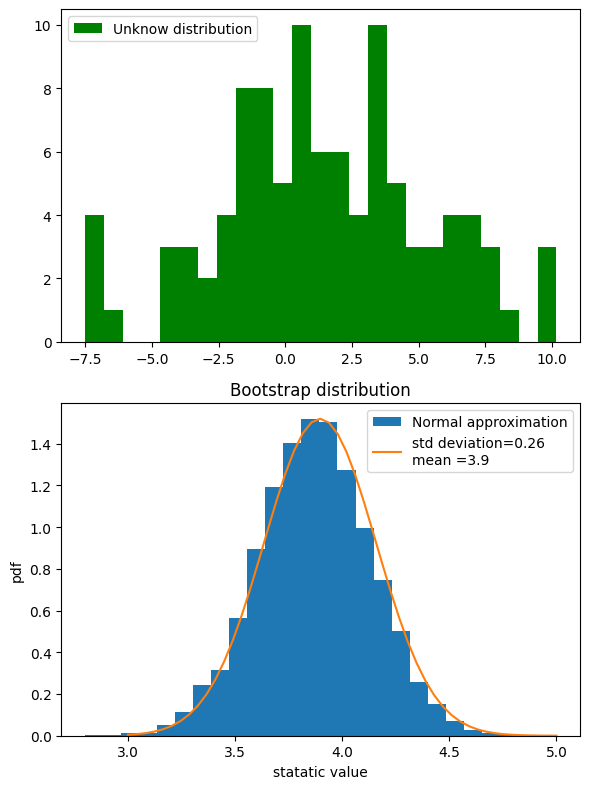

In [4]:
rng = np.random.default_rng()
from scipy.stats import norm
dist = norm(loc = 2, scale = 4) # unknow distribution
data = dist.rvs(size = 100, random_state=rng)

std_true = dist.std()
print(std_true)

std_sample = np.std(data)
print(std_sample)

data = (data,) # samples must be in a sequence
res = bootstrap(data, np.std, confidence_level= 0.95, rng = rng)
fig, axes = plt.subplots(2, 1, figsize = (6,8))
axes[0].hist(data, bins = 25, color = 'g', label = 'Unknow distribution')
#axes[0].set_title('Unknow distribution')
axes[0].legend()
axes[1].hist(res.bootstrap_distribution, bins = 25, density=True, label = 'Normal approximation')
x = np.linspace(3, 5)
pdf = norm.pdf(x, loc = std_sample, scale = res.standard_error)
axes[1].plot(x, pdf, label = f'std deviation={np.round(res.standard_error,2)}\nmean ={np.round(std_sample,2)}')
axes[1].set_title('Bootstrap distribution')
axes[1].set_ylabel('pdf')
axes[1].set_xlabel('statatic value')
axes[1].legend()
plt.tight_layout()

plt.show();